In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [2]:
df_24 = pd.read_excel("2024-yili-arama-kurtarma.xlsx")
df_24["YIL"] = 2024

df_25 = pd.read_excel("2025-yili-arama-kurtarma-cizelgesi.xlsx")
df_25["YIL"] = 2025

df_all = pd.concat([df_24,df_25], ignore_index=True)

In [3]:
df_all = df_all[["YIL", "KURTARMA_TURU", "CIKIS_SAATI", "VARIS_SURESI", "MAHALLE", "ILCE", ]].copy()

In [4]:
df_all.head()

,YIL,KURTARMA_TURU,CIKIS_SAATI,VARIS_SURESI,MAHALLE,ILCE
0,2024,112 ACİL SAĞLIK/AMBULANS,00:41,00:04,GÜNEY,KONAK
1,2024,112 ACİL SAĞLIK/AMBULANS,00:50,NaN,GÜMÜŞPALA,BAYRAKLI
2,2024,TRAFİK KAZASI,01:26,00:04,KURUÇEŞME,BUCA
3,2024,112 ACİL SAĞLIK/AMBULANS,01:58,00:07,BOSTANLI,KARŞIYAKA
4,2024,YÜZÜK KESME,02:42,00:03,KAZIMDİRİK,BORNOVA


In [5]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24571 entries, 0 to 24570
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   YIL            24571 non-null  int64 
 1   KURTARMA_TURU  24571 non-null  object
 2   CIKIS_SAATI    24571 non-null  object
 3   VARIS_SURESI   24469 non-null  object
 4   MAHALLE        24540 non-null  object
 5   ILCE           24571 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.1+ MB


In [6]:
df_all.isnull().sum()

YIL                0
KURTARMA_TURU      0
CIKIS_SAATI        0
VARIS_SURESI     102
MAHALLE           31
ILCE               0
dtype: int64

In [7]:
df_all.dropna(subset=["VARIS_SURESI", "MAHALLE"], inplace=True)
df_all.isnull().sum()

YIL              0
KURTARMA_TURU    0
CIKIS_SAATI      0
VARIS_SURESI     0
MAHALLE          0
ILCE             0
dtype: int64

In [8]:
df_all["ILCE"].unique()

array(['KONAK', 'BUCA', 'KARŞIYAKA', 'BORNOVA', 'GAZİEMİR', 'KARABAĞLAR',
       'BALÇOVA', 'URLA', 'SEFERİHİSAR', 'ÇİĞLİ', 'FOÇA', 'KİRAZ',
       'ÇEŞME', 'ALİAĞA', 'SELÇUK', 'ÖDEMİŞ', 'TORBALI', 'DİKİLİ',
       'BAYRAKLI', 'GÜZELBAHÇE', 'NARLIDERE', 'MENDERES', 'MENEMEN',
       'KARABURUN', 'BERGAMA', 'KEMALPAŞA', 'TİRE', 'KINIK', 'BAYINDIR',
       'İL DIŞI', 'BEYDAĞ'], dtype=object)

In [9]:
df_all = df_all[df_all["ILCE"] != "İL DIŞI"]
df_all["ILCE"].unique()

array(['KONAK', 'BUCA', 'KARŞIYAKA', 'BORNOVA', 'GAZİEMİR', 'KARABAĞLAR',
       'BALÇOVA', 'URLA', 'SEFERİHİSAR', 'ÇİĞLİ', 'FOÇA', 'KİRAZ',
       'ÇEŞME', 'ALİAĞA', 'SELÇUK', 'ÖDEMİŞ', 'TORBALI', 'DİKİLİ',
       'BAYRAKLI', 'GÜZELBAHÇE', 'NARLIDERE', 'MENDERES', 'MENEMEN',
       'KARABURUN', 'BERGAMA', 'KEMALPAŞA', 'TİRE', 'KINIK', 'BAYINDIR',
       'BEYDAĞ'], dtype=object)

In [10]:
def sureyi_hesapla(x):
    if not isinstance(x, str) or ":" not in str(x):
        return 0

    parcalar = x.split(':')
    return int(parcalar[0]) * 60 + int(parcalar[1])

        

In [11]:
df_all["VARIS_SURESI_DK"] = df_all["VARIS_SURESI"].apply(sureyi_hesapla)
df_all = df_all[df_all["VARIS_SURESI_DK"] > 0]

In [12]:
df_all = df_all[df_all["KURTARMA_TURU"] == "TRAFİK KAZASI"]
f"Toplam trafik kazası {len(df_all)}"

'Toplam trafik kazası 2014'

In [13]:
df_all.describe()

,YIL,VARIS_SURESI_DK
count,2014.000000,2014.000000
mean,2024.444886,6.230884
std,0.497077,5.216697
min,2024.000000,1.000000
25%,2024.000000,4.000000
50%,2024.000000,5.000000
75%,2025.000000,7.000000
max,2025.000000,80.000000


In [41]:
yillik_ozet = df_all.groupby('YIL')['VARIS_SURESI_DK'].mean()
print("Yıllara Göre Ortalama Varış Süreleri:")
print(yillik_ozet)

Yıllara Göre Ortalama Varış Süreleri:
YIL
2024    6.157424
2025    6.322545
Name: VARIS_SURESI_DK, dtype: float64


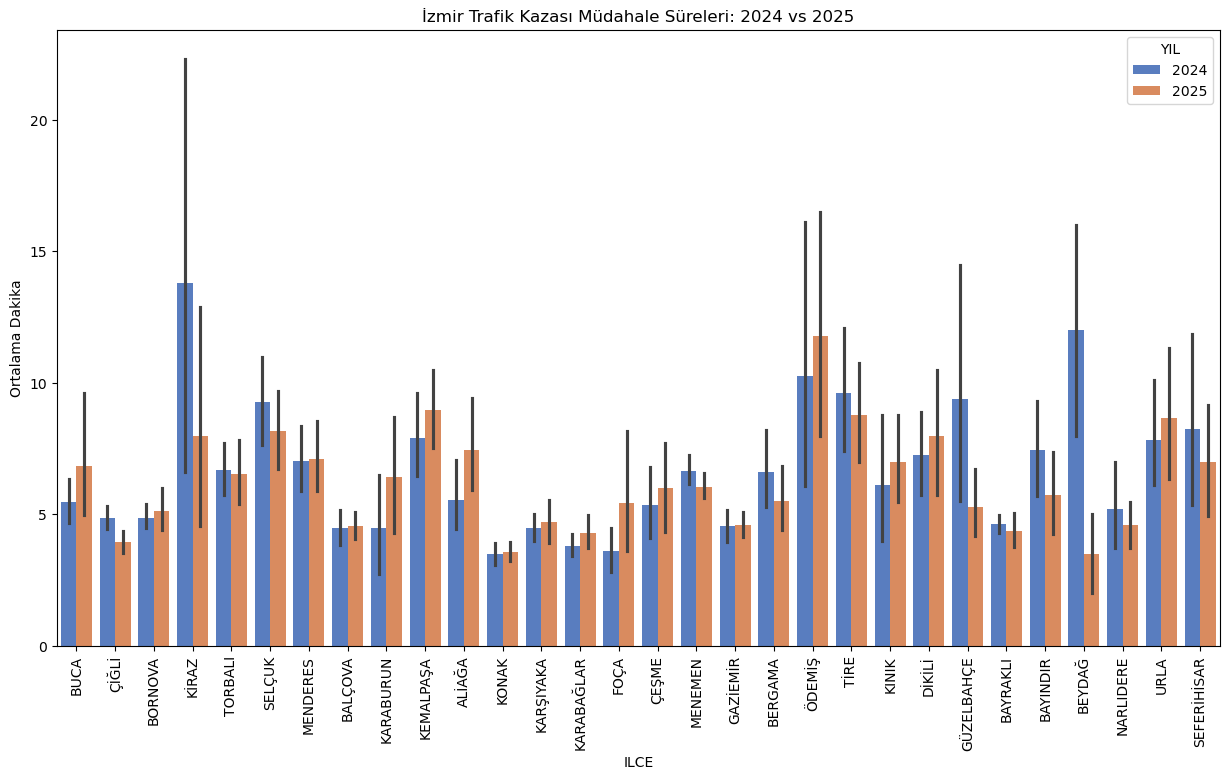

In [14]:
plt.figure(figsize=(15, 8))
sns.barplot(x='ILCE', y='VARIS_SURESI_DK', hue='YIL', data=df_all, palette='muted')
plt.title('İzmir Trafik Kazası Müdahale Süreleri: 2024 vs 2025')
plt.xticks(rotation=90)
plt.ylabel('Ortalama Dakika')
plt.savefig("trafik-kazasi-mudahale-karsilastirma.png")
plt.show()

In [15]:
le = LabelEncoder()
df_all['ILCE_KOD'] = le.fit_transform(df_all['ILCE'])
df_all['SAAT_KOD'] = pd.to_datetime(df_all['CIKIS_SAATI'], format='%H:%M').dt.hour

train = df_all[df_all['YIL'] == 2024]
test = df_all[df_all['YIL'] == 2025]

X_train, y_train = train[['ILCE_KOD', 'SAAT_KOD']], train['VARIS_SURESI_DK']
X_test, y_test = test[['ILCE_KOD', 'SAAT_KOD']], test['VARIS_SURESI_DK']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
tahmin = model.predict(X_test)

hata = mean_absolute_error(y_test, tahmin)
print(f"2024 Modeliyle 2025 Tahmin Hatası (MAE): {hata:.2f} Dakika")

2024 Modeliyle 2025 Tahmin Hatası (MAE): 3.19 Dakika


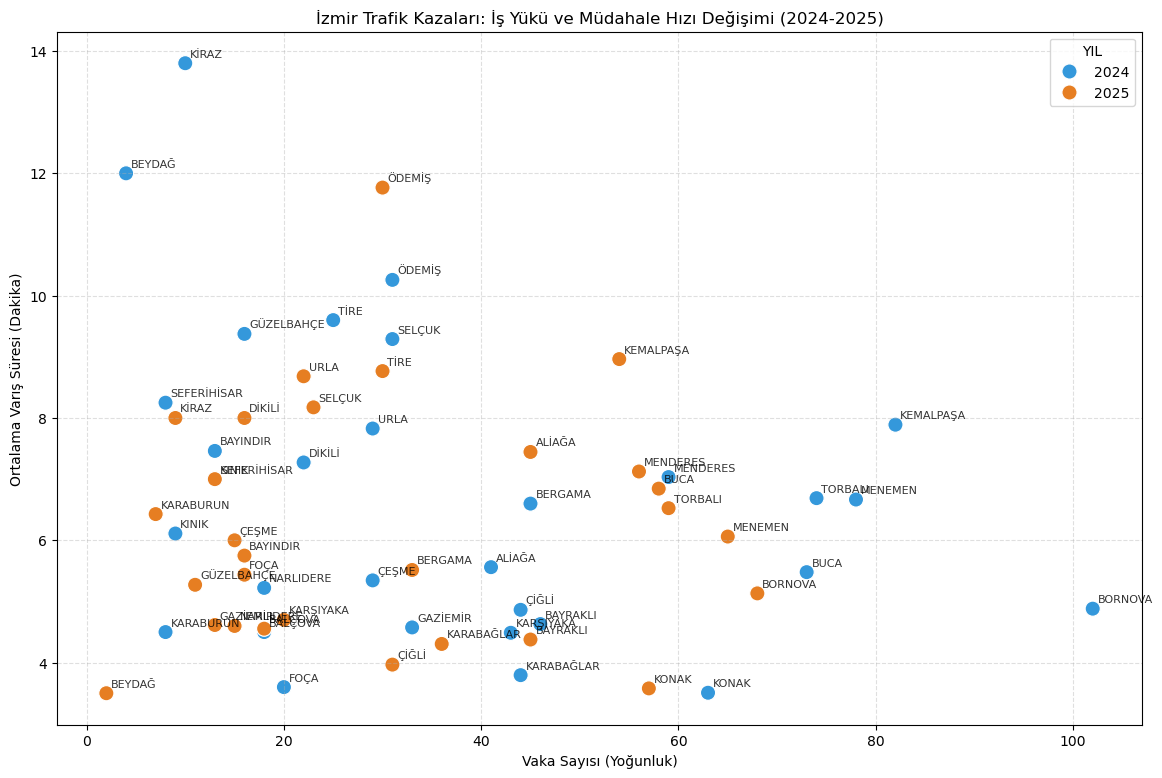

In [18]:
# 1. Önce sütun isimlerindeki gizli boşlukları temizleyelim (Hata almamak için)
df_all.columns = df_all.columns.str.strip()

# 2. Tek satırda 2024 ve 2025 özetini çıkaralım
ozet_all = df_all[df_all['KURTARMA_TURU'] == 'TRAFİK KAZASI'].groupby(['YIL', 'ILCE'])['VARIS_SURESI_DK'].agg(['count', 'mean']).reset_index()

# 3. Scatter Plot çizimi
plt.figure(figsize=(14, 9))
sns.scatterplot(data=ozet_all, x='count', y='mean', hue='YIL', s=120, palette=['#3498db', '#e67e22'])

# İlçe isimlerini ekleyelim
for i in range(ozet_all.shape[0]):
    plt.text(ozet_all['count'].iloc[i] + 0.5, 
             ozet_all['mean'].iloc[i] + 0.1, 
             ozet_all['ILCE'].iloc[i], 
             fontsize=8, alpha=0.8)

plt.title('İzmir Trafik Kazaları: İş Yükü ve Müdahale Hızı Değişimi (2024-2025)')
plt.xlabel('Vaka Sayısı (Yoğunluk)')
plt.ylabel('Ortalama Varış Süresi (Dakika)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig("trafik-kazalari-mudahale-hiz-degisimi")
plt.show()

In [19]:
print(df_all.columns.tolist())

['YIL', 'KURTARMA_TURU', 'CIKIS_SAATI', 'VARIS_SURESI', 'MAHALLE', 'ILCE', 'VARIS_SURESI_DK', 'ILCE_KOD', 'SAAT_KOD']
